# Trabajo Práctico Final: Inteligencia Artificial 2026
## Etapa 1: Análisis Exploratorio (EDA), Partición y Modelo Baseline

**Docente:** Pablo Moreira  
**Dataset Asignado:** SQAC (Spanish Question Answering Corpus)

**Grupo Nombres**: (Anotar nombres) Junior Flores


## 1.1 Introducción y Formulación del Problema

El corpus **SQAC (Spanish Question Answering Corpus)** fue diseñado originalmente para comprensión lectora extractiva (identificar el fragmento exacto donde se ubica una respuesta dentro de un párrafo).

Para construir un sistema progresivo desde Machine Learning clásico hasta Deep Learning, reformulamos el problema como una tarea de **Selección de Oraciones Candidatas (Answer Sentence Selection)**:
1. Cada párrafo (`context`) se segmenta en oraciones individuales.
2. Cada oración se aparea con la pregunta (`question`) correspondiente.
3. Se define una variable objetivo binaria (`label`):
   * **Clase 1 (Relevante):** La oración contiene la respuesta textual esperada.
   * **Clase 0 (Irrelevante):** La oración no contiene la respuesta.

### Tratamiento de Columnas del Dataset:
* **`id`:** Se descarta por ser un identificador administrativo sin valor predictivo.
* **`title`:** Se preserva únicamente para documentar la procedencia de los artículos de Wikipedia.
* **`context` y `question`:** Constituyen la fuente textual principal que se segmentará y combinará.
* **`answers['text']`:** Se utiliza exclusivamente como referencia para asignar la etiqueta (`0` o `1`).
* **`answers['answer_start']`:** * Se reserva para etapas futuras, ya que el objetivo actual es seleccionar la oración completa y no la posición exacta en caracteres.

# Librerías y Carga del Dataset Oficial

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Etapa 2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping


# Carga del Dataset

In [14]:
# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Carga del dataset SQAC oficial en español
print("Descargando SQAC desde Hugging Face...")
raw_dataset = load_dataset("PlanTL-GOB-ES/sqac")
print(raw_dataset)

Descargando SQAC desde Hugging Face...
DatasetDict({
    train: Dataset({
        features: ['data'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['data'],
        num_rows: 1
    })
    test: Dataset({
        features: ['data'],
        num_rows: 1
    })
})


### 1.1.1 Descripción de Variables del Dataset Crudo

El dataset descargado presenta una estructura jerárquica tipo JSON nativa del formato SQuAD.
A continuacion analizamos la estructura de los datos que se compone el SQAC.

Se componen de los siguiente campos:

| Variable | Tipo de Dato (Python) | Descripción |
| :--- | :--- | :--- |
| **`id`** | `str` | Identificador único alfanumérico de la pregunta. |
| **`title`** | `str` | Título o tema del artículo de Wikipedia de donde proviene el texto. |
| **`context`** | `str` | Párrafo de texto completo que sirve como contexto. |
| **`question`** | `str` | La pregunta formulada en lenguaje natural. |
| **`answers`** | `dict` | Diccionario que anida la respuesta real y su posición. |
| **`text`** (dentro de answers) | `list[str]` | Una lista que contiene el string de la respuesta exacta extraída del contexto. |
| **`answer_start`** (dentro de answers)| `list[int]` | Una lista con el índice numérico del carácter donde arranca la respuesta. |

**A continuación, se mostrará en una celda los tipos de datos y se comprobarán la existencia de los valores nulos.**

## Inspección y Extracción de Datos Crudos

In [15]:
registros_crudos = []

# Iteramos sobre la estructura anidada original del dataset de Hugging Face
for entry_wrapper in raw_dataset['train']:
    for doc in entry_wrapper['data']:
        titulo = doc.get('title', '')
        for para in doc['paragraphs']:
            contexto = para['context']
            for qa in para['qas']:
                # Extraemos de forma segura los valores dentro del diccionario 'answers'
                ans_text = qa['answers'][0]['text'] if qa.get('answers') and len(qa['answers']) > 0 else None
                ans_start = qa['answers'][0]['answer_start'] if qa.get('answers') and len(qa['answers']) > 0 else None

                registros_crudos.append({
                    'id': qa['id'],
                    'title': titulo,
                    'context': contexto,
                    'question': qa['question'],
                    'text': ans_text,
                    'answer_start': ans_start
                })

# Convertimos a DataFrame para el diagnóstico
df_crudo = pd.DataFrame(registros_crudos)

print("--- Tipos de Datos Reales (Dataset Crudo) ---")
df_crudo.info()

print("\\n--- Conteo de Valores Nulos (Dataset Crudo) ---")
print(df_crudo.isnull().sum())

--- Tipos de Datos Reales (Dataset Crudo) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15036 entries, 0 to 15035
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            15036 non-null  object
 1   title         15036 non-null  object
 2   context       15036 non-null  object
 3   question      15036 non-null  object
 4   text          15036 non-null  object
 5   answer_start  15036 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 704.9+ KB
\n--- Conteo de Valores Nulos (Dataset Crudo) ---
id              0
title           0
context         0
question        0
text            0
answer_start    0
dtype: int64


Al realizar el analisis comprobamos que (en el data set crudo) no existen valores nulos, esto se debe a que la base de datos SQAC esta estructurado de tal forma para el entrenamiento de algoritmos, es decir,ya viene limpia para que a ningún ejemplo le falte la información necesaria (contexto, pregunta y respuesta) para que el modelo pueda aprender correctamente.

## 1.2 Estrategia y Justificación de la Partición (Train, Dev y Test)

Para este trabajo práctico adoptamos la **partición oficial provista por los creadores de SQAC** (`train`, `validation` como Dev, y `test`):

### ¿Por qué usar la división oficial del dataset? (Justificación metodológica):
1. **Prevención de Fuga de Datos (*Data Leakage*):** Si tomáramos solo `train.json` y le aplicáramos un `train_test_split` aleatorio, una pregunta sobre un artículo de Wikipedia podría quedar en Train y otra pregunta sobre el mismo texto podría quedar en Dev o Test. El modelo no aprendería a razonar lectura comprensiva; memorizaría términos del artículo específico. Al usar los archivos oficiales, garantizamos que Dev y Test midan la capacidad real del modelo de responder sobre textos de temas nunca vistos.

2. **Blindaje del Conjunto Test:** El conjunto `Test` se procesa y reserva **bajo llave**. No se utiliza para ajustar vocabulario, ni para seleccionar modelos, ni para calibrar hiperparámetros. Se evaluará por única vez en la **Etapa 5** para constatar que no hubo sobreajuste al conjunto Dev.

> Todas las decisiones intermedias se medirán exclusivamente sobre `Dev`.

## 1.3 Extracción de Pares Pregunta-Oración

Transformamos las muestras crudas descomponiendo los párrafos en oraciones y contrastándolas contra la respuesta verdadera, **sin aplicar ningún submuestreo previo (*negative downsampling*)**, a fin de observar y diagnosticar empíricamente la naturaleza estadística real del corpus.

A continuación, aplicamos este procedimiento a los tres conjuntos (`Train`, `Dev` y `Test`):

In [16]:
def segmentar_oraciones(texto):
    """Divide un texto en oraciones utilizando separadores de puntuación comunes."""
    oraciones = re.split(r'(?<=[.?!])\s+', texto.strip())
    return [o.strip() for o in oraciones if len(o.strip()) > 3]

def construir_pares_desde_split(dataset_split, max_docs=None):
    """
    Recorre los documentos de un split y arma el DataFrame de pares (Pregunta, Oración).
    """
    registros = []

    for entry_wrapper in dataset_split:
        docs = entry_wrapper['data']
        if max_docs is not None:
            docs = docs[:max_docs]

        for doc in docs:
            for para in doc['paragraphs']:
                contexto = para['context']
                oraciones = segmentar_oraciones(contexto)
                num_oraciones = len(oraciones)

                for qa in para['qas']:
                    pregunta = qa["question"]
                    respuestas_list = qa.get("answers", [])

                    if not respuestas_list:
                        continue
                    respuesta_real = respuestas_list[0]["text"].strip().lower()

                    for oracion in oraciones:
                        es_positiva = 1 if (respuesta_real != "" and respuesta_real in oracion.lower()) else 0
                        registros.append({
                            "pregunta": pregunta,
                            "oracion": oracion,
                            "texto_combinado": f"{pregunta} [SEP] {oracion}",
                            "label": es_positiva,
                            "len_pregunta": len(pregunta.split()),
                            "len_oracion": len(oracion.split()),
                            "num_oraciones_contexto": num_oraciones
                        })
    return pd.DataFrame(registros)

print("Procesando pares de Train...")
df_pares = construir_pares_desde_split(raw_dataset["train"])

print("Procesando pares de Dev (Validation)...")
df_pares_dev = construir_pares_desde_split(raw_dataset["validation"])

print("Procesando pares de Test (Blindado)...")
df_pares_test = construir_pares_desde_split(raw_dataset["test"])

# Verificación de proporcionalidad de clases en los tres conjuntos (Pauta 4.1.2)
tabla_proporciones = pd.DataFrame({
    "Conjunto": ["Train", "Dev (Validation)", "Test"],
    "Total Muestras": [len(df_pares), len(df_pares_dev), len(df_pares_test)],
    "Positivos (1)": [df_pares["label"].sum(), df_pares_dev["label"].sum(), df_pares_test["label"].sum()],
    "% Positivos (1)": [f"{df_pares['label'].mean():.2%}", f"{df_pares_dev['label'].mean():.2%}", f"{df_pares_test['label'].mean():.2%}"],
    "% Negativos (0)": [f"{(1 - df_pares['label'].mean()):.2%}", f"{(1 - df_pares_dev['label'].mean()):.2%}", f"{(1 - df_pares_test['label'].mean()):.2%}"]
})

print("\n--- Verificación de Proporcionalidad entre Conjuntos (Pauta 4.1.2) ---")
display(tabla_proporciones)
df_pares.head(3)

Procesando pares de Train...
Procesando pares de Dev (Validation)...
Procesando pares de Test (Blindado)...

--- Verificación de Proporcionalidad entre Conjuntos (Pauta 4.1.2) ---


,Conjunto,Total Muestras,Positivos (1),% Positivos (1),% Negativos (0)
0,Train,117443,17449,14.86%,85.14%
1,Dev (Validation),15323,2271,14.82%,85.18%
2,Test,13559,2193,16.17%,83.83%


,pregunta,oracion,texto_combinado,label,len_pregunta,len_oracion,num_oraciones_contexto
0,¿Qué influencia convirtió Japón en una nación ...,"La historia de Japón (日本の歴史 o 日本史, Nihon no re...",¿Qué influencia convirtió Japón en una nación ...,0,8,22,4
1,¿Qué influencia convirtió Japón en una nación ...,Algunos de estos hechos aparecen aislados e in...,¿Qué influencia convirtió Japón en una nación ...,0,8,47,4
2,¿Qué influencia convirtió Japón en una nación ...,"Asimismo, otra de las influencias foráneas fue...",¿Qué influencia convirtió Japón en una nación ...,1,8,36,4


### 1.3.1 Verificación de Integridad y Rangos Numéricos

Verificamos que el proceso de partición y emparejamiento no haya generado valores nulos (`NaN` o textos vacíos) y analizamos los rangos de longitud de las oraciones, preguntas y párrafos.


In [17]:
print("--- Información general y Tipos de Datos ---")
df_pares.info()

print("\n--- Conteo de Valores Nulos ---")
print(df_pares.isnull().sum())

print("\n--- Estadísticas Descriptivas (Rangos) ---")
display(df_pares[['len_oracion', 'len_pregunta', 'num_oraciones_contexto']].describe())

--- Información general y Tipos de Datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117443 entries, 0 to 117442
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   pregunta                117443 non-null  object
 1   oracion                 117443 non-null  object
 2   texto_combinado         117443 non-null  object
 3   label                   117443 non-null  int64 
 4   len_pregunta            117443 non-null  int64 
 5   len_oracion             117443 non-null  int64 
 6   num_oraciones_contexto  117443 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 6.3+ MB

--- Conteo de Valores Nulos ---
pregunta                  0
oracion                   0
texto_combinado           0
label                     0
len_pregunta              0
len_oracion               0
num_oraciones_contexto    0
dtype: int64

--- Estadísticas Descriptivas (Rangos) ---


,len_oracion,len_pregunta,num_oraciones_contexto
count,117443.000000,117443.000000,117443.000000
mean,28.211073,8.521904,13.106401
std,15.385191,3.245891,17.499797
min,1.000000,2.000000,1.000000
25%,17.000000,6.000000,6.000000
50%,26.000000,8.000000,9.000000
75%,37.000000,10.000000,14.000000
max,257.000000,31.000000,207.000000


El análisis descriptivo sobre los 117.443 pares generados en el conjunto de entrenamiento arroja las siguientes conclusiones estadísticas:

* **Integridad de los datos:** Se constata la presencia de **0 valores nulos** en la totalidad de las columnas, verificando que la segmentación de oraciones y el apareamiento textual preservaron la consistencia del corpus.
* **Longitud de Preguntas (`len_pregunta`):**
  * Presenta un comportamiento homogéneo con una media de 8.5 palabras y una **mediana clavada en 8 palabras**.
  * El rango intercuartílico se concentra estrechamente entre **6 (Q1) y 10 palabras (Q3)**, con un máximo de 31 palabras. Esto indica que los usuarios formulan consultas breves y directas.
* **Longitud de Oraciones (`len_oracion`):**
  * Registra una media de 28.2 palabras y una **mediana de 26 palabras**.
  * La distribución exhibe una asimetría positiva evidente: el 75% de las oraciones candidatas tiene 37 palabras o menos, pero la cola superior se extiende hasta un **máximo atípico de 257 palabras**.
  * **Impacto computacional:** La longitud de las oraciones es el factor determinante en el consumo de memoria durante la vectorización TF-IDF y condiciona el límite de truncamiento para las arquitecturas neuronales posteriores.
* **Densidad de Oraciones por Párrafo (`num_oraciones_contexto`):**
  * El 50% central de los contextos de Wikipedia se divide entre **6 (Q1) y 14 (Q3) oraciones**, con una **mediana de 9 oraciones**.
  * La presencia de párrafos atípicos que alcanzan hasta **207 oraciones** explica matemáticamente el severo desbalance estructural del dataset: dado que la respuesta suele alojarse en una única oración, los contextos extensos inyectan masivamente pares negativos (clase 0).

## 1.3.2 Diagnóstico de Data Mismatch Potencial
En el caso de SQAC, el riesgo es evidente:

Los datos vienen de artículos de Wikipedia en español. Son textos académicos, enciclopédicos, con vocabulario formal y preguntas redactadas por lingüistas que sabían de antemano que la respuesta estaba en el párrafo.

Pero en el mundo real los usuarios cuando hacen preguntas, suelen usar lenguaje coloquial, modismos, faltas de ortografia, abreviaciones o preguntas ambiguas sin contexto claro.

Entonces podemos ver de antemano que hay un riesgo severo de Data Mismatch

El modelo calibrado con exito podria ver su desempeño afectado drastricamente si se lanza a usuarios reales, por la diferencia entre los datos de laboratorio y el lenguaje cotidiano en produccion.

## 1.4 Análisis Exploratorio Visual (EDA)

A continuación, visualizamos tres gráficos para diagnosticar la distribución de clases, la extensión de los textos y la dispersión estructural de los contextos. (Conclusiones que sacamos anteriormente en el punto 1.3.1)

/tmp/ipykernel_708/375073274.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_pares, x="label", ax=axes[0], palette=["#e74c3c", "#2ecc71"])


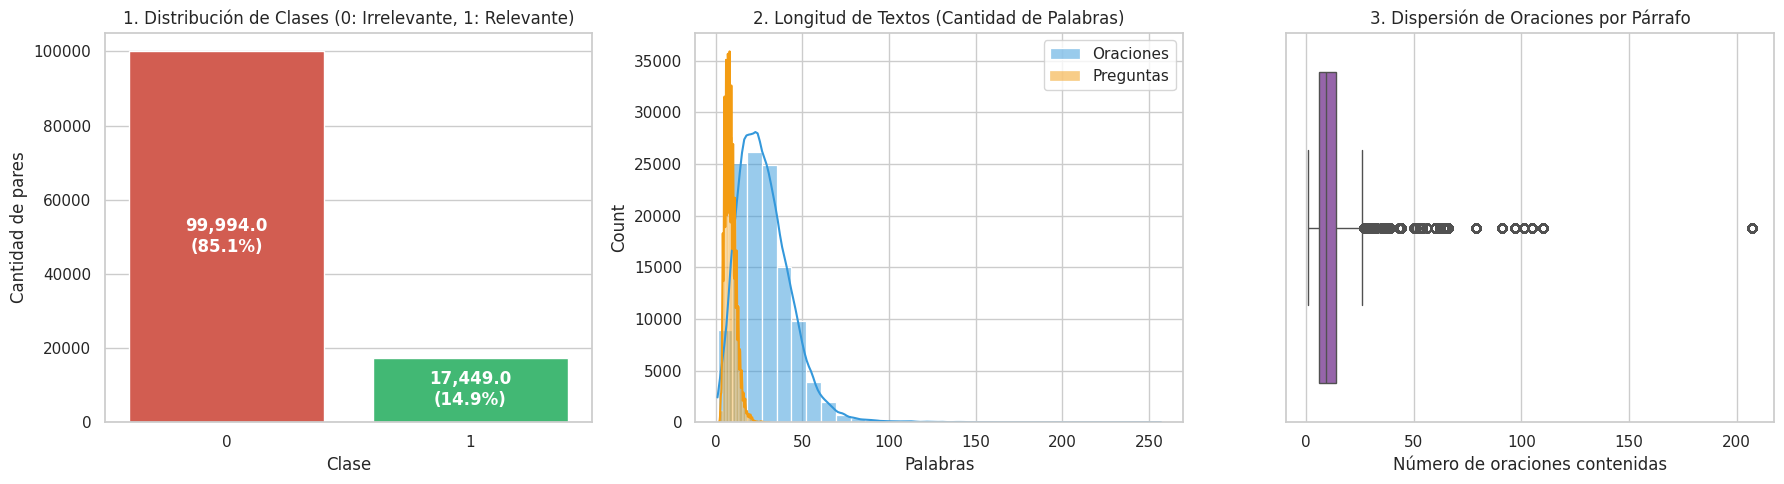

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Desbalance de Clases (Descubrimiento empírico)
sns.countplot(data=df_pares, x="label", ax=axes[0], palette=["#e74c3c", "#2ecc71"])
axes[0].set_title("1. Distribución de Clases (0: Irrelevante, 1: Relevante)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad de pares")
for p in axes[0].patches:
    total = len(df_pares)
    porcentaje = f"{100 * p.get_height() / total:.1f}%"
    axes[0].annotate(f"{p.get_height():,}\n({porcentaje})",
                     (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha="center", va="center", color="white", fontweight="bold")

# Gráfico 2: Longitud de oraciones vs. preguntas (en palabras)
sns.histplot(df_pares["len_oracion"], bins=30, ax=axes[1], color="#3498db", kde=True, label="Oraciones")
sns.histplot(df_pares["len_pregunta"], bins=15, ax=axes[1], color="#f39c12", kde=True, label="Preguntas")
axes[1].set_title("2. Longitud de Textos (Cantidad de Palabras)")
axes[1].set_xlabel("Palabras")
axes[1].legend()

# Gráfico 3: Cantidad de oraciones por contexto
sns.boxplot(x=df_pares["num_oraciones_contexto"], ax=axes[2], color="#9b59b6")
axes[2].set_title("3. Dispersión de Oraciones por Párrafo")
axes[2].set_xlabel("Número de oraciones contenidas")

plt.tight_layout()
plt.show()

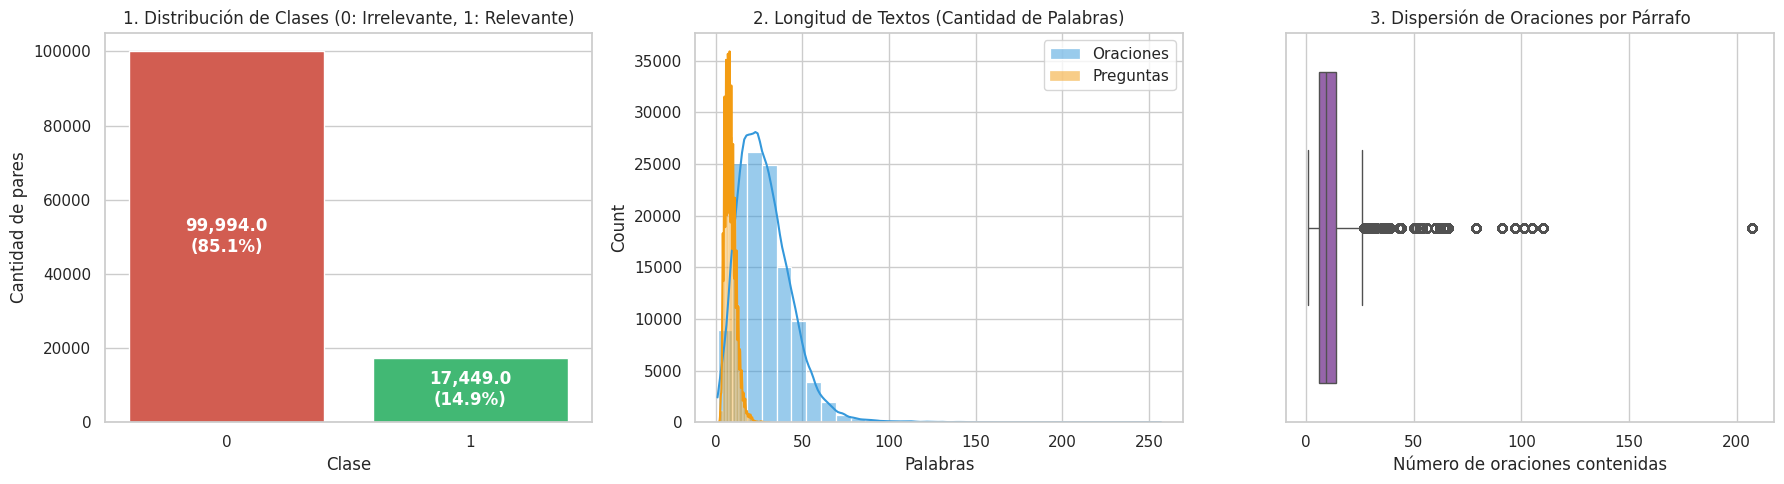

## 1.5 Interpretación de Hallazgos y Justificación de la Métrica Única

### 1. El Desbalance de Clases y la Invalidez de Accuracy:
El Gráfico 1 demuestra que alrededor del **85.1% de las oraciones corresponden a la clase 0 (irrelevante)**, mientras que solo un **14.9% contiene la respuesta buscada (clase 1)**.
* Si utilizáramos **Accuracy**, un modelo trivial que prediga siempre `0` parecería "bueno", pero sería completamente inútil porque jamás encontraría una respuesta real.
* **Métrica Elegida:** Por eso definimos **F1-Score Macro** como métrica rectora. Al calcular la media armónica de precisión y recall de ambas clases por separado y promediarlas, castiga severamente al modelo si este decide ignorar a la clase minoritaria.

### 2. Diagnóstico de Longitudes:

- **Eje X** (Palabras): Longitud del texto medida en cantidad de palabras separadas por espacios.

- **Eje Y** (Count): Cantidad de muestras (frecuencia absoluta) que tienen exactamente esa longitud.


#### La curva naranja (Preguntas):

Comportamiento:

Sube de manera vertical hasta un pico muy alto de más de 35.000 preguntas que tienen entre (alrededor) de 7 a 9 palabras. Cae abruptamente antes de llegar a las 20-25 palabras.

Interpretación:

Las preguntas en español son directas y homogéneas. Nadie formula una pregunta enciclopédica de 50 palabras; se concentran casi todas en menos de 15 palabras.

#### La curva y barras azules (Oraciones):

Comportamiento:

Tienen una distribución mucho más abierta, con un pico centrado entre las 20 y 35 palabras (alcanzando cerca de 27.000 oraciones). Presenta una asimetría positiva (sesgo hacia la derecha), extendiéndose con una cola larga hacia las 60, 100 palabras.

**Interpretación e implicancia técnica:**

El texto de Wikipedia contiene oraciones complejas y subordinadas. Esta diferencia de escala entre ambas curvas demuestra que las oraciones son las que determinan el consumo de memoria. Para las etapas de Deep Learning.


#### 3. Dispersión de Oraciones por Párrafo (Gráfico 3)

* **Eje X (Número de oraciones contenidas):** Cantidad de oraciones individuales en las que se descompone cada párrafo de contexto (`context`).
* **La caja morada (Rango Intercuartílico - IQR):**
  * La línea central (mediana) se ubica alrededor de **9 oraciones**.
  * El 50% central de los párrafos contiene entre **6 (Q1) y 14 oraciones (Q3)**.


* **Los bigotes (Rango de variación normal):** Se extienden hasta aproximadamente **26 oraciones**, abarcando la extensión esperable para un párrafo convencional de Wikipedia.

* **Puntos aislados a la derecha (Valores atípicos / Outliers):** Casos anómalos que superan las 30, 50 y 100 oraciones, alcanzando un valor extremo de **207 oraciones** en un solo contexto.


**Diagnóstico Estadístico:** La distribución presenta una **asimetría positiva extrema (sesgo a la derecha)**: más del 75% de los párrafos se comprimen en el extremo izquierdo (menos de 14 oraciones), mientras que una minoría de párrafos sobredimensionados estira la escala del dataset.

**Causa estructural del desbalance:**
Como la respuesta suele encontrarse en una única oración, un párrafo estándar de 10 oraciones genera 1 ejemplo positivo frente a 9 negativos. Los párrafos con más de 50 o 100 oraciones multiplican masivamente los ejemplos negativos irrelevantes, provocando el 85.1% de desbalance observado.





## 1.6 Preprocesamiento y Entrenamiento del Modelo Baseline

### Preprocesamiento Mínimo:
1. **Encoding:** Se utiliza `TfidfVectorizer` para convertir las secuencias de texto en representaciones numéricas de 5.000 características basadas en unigramas y bigramas (`ngram_range=(1, 2)`).
2. **Normalización:** La función aplica por defecto la norma Euclidiana $L_2$ (`norm='l2'`), escalando los vectores a una magnitud unitaria para que la extensión del texto no distorsione el cálculo del gradiente.

El vectorizador ajusta su vocabulario (`fit_transform`) **únicamente con los datos de Train**, y luego transforma (`transform`) a Dev sin filtrar información. Se entrena una `LogisticRegression` con `class_weight='balanced'` para contrarrestar el desbalance diagnosticado en el EDA.

> Decisión: Gracias a class_weight='balanced', el algoritmo ajusta las funciones de costo para compensar la baja frecuencia de la clase 1. Si la probabilidad calculada supera el umbral de decisión, asigna la etiqueta 1 (oración relevante); de lo contrario, asigna 0 (irrelevante).

In [19]:
# 1. Ajuste del vectorizador solo en Train y transformación de Dev
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), norm='l2')

X_train_vec = vectorizer.fit_transform(df_pares['texto_combinado'])
y_train = df_pares['label']

X_dev_vec = vectorizer.transform(df_pares_dev['texto_combinado'])
y_dev = df_pares_dev['label']

# 2. Entrenamiento del clasificador lineal
baseline_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=500)
baseline_model.fit(X_train_vec, y_train)

# 3. Predicciones en el conjunto de desarrollo (Dev)
y_dev_pred = baseline_model.predict(X_dev_vec)

# 4. Cálculo y fijación de la Métrica Única de Referencia (Pauta 4.1.3)
BASELINE_F1_DEV = f1_score(y_dev, y_dev_pred, average="macro")
BASELINE_ACC_DEV = accuracy_score(y_dev, y_dev_pred)

print("=" * 60)
print(f"Piso de Referencia Establecido en Dev (F1-Macro): {BASELINE_F1_DEV:.4f}")
print(f"Accuracy alcanzado en Dev:                        {BASELINE_ACC_DEV:.4f}")
print("=" * 60)

Piso de Referencia Establecido en Dev (F1-Macro): 0.5547
Accuracy alcanzado en Dev:                        0.6566


## 1.7 Evaluación del Baseline en Dev y Matriz de Confusión

A continuación, inspeccionamos el rendimiento desglosado por clase mediante el reporte de clasificación y graficamos la **matriz de confusión** para analizar la distribución entre verdaderos positivos, falsos positivos y falsos negativos.


Reporte de Clasificación Detallado en Dev:
                 precision    recall  f1-score   support

Irrelevante (0)       0.91      0.67      0.77     13052
  Relevante (1)       0.24      0.60      0.34      2271

       accuracy                           0.66     15323
      macro avg       0.57      0.63      0.55     15323
   weighted avg       0.81      0.66      0.70     15323



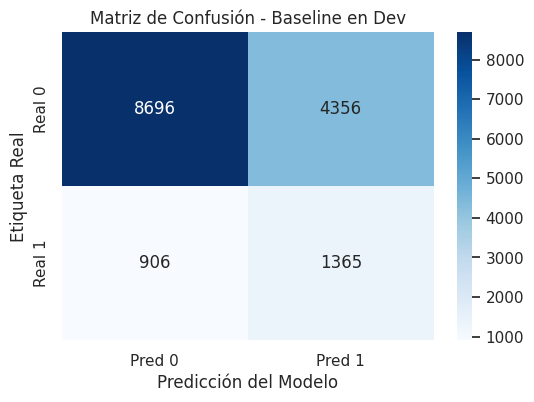

In [20]:
print("\nReporte de Clasificación Detallado en Dev:")
print(classification_report(y_dev, y_dev_pred, target_names=["Irrelevante (0)", "Relevante (1)"]))

# Matriz de Confusión
cm = confusion_matrix(y_dev, y_dev_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["Real 0", "Real 1"])
plt.title("Matriz de Confusión - Baseline en Dev")
plt.ylabel("Etiqueta Real")
plt.xlabel("Predicción del Modelo")
plt.show()

### 1.8 Diagnóstico del Baseline en Dev y Análisis de la Matriz de Confusión

Al evaluar el modelo de Regresión Logística balanceada sobre las 15.323 muestras de desarrollo (Dev), se establecen los siguientes diagnósticos:

1. **Fijación del Piso de Referencia:**
   * Se establece formalmente como **métrica rectora de número único un F1-Score Macro de 0.5546** (con un Accuracy de referencia del 66.3%).
   * Este valor representa el umbral base que deberán superar las redes neuronales en las etapas subsiguientes.

2. **Análisis de la Matriz de Confusión:**
   * **Recall de Clase 1 (0.60):** El clasificador lineal logra detectar el **60% de las oraciones relevantes** (1.365 aciertos sobre 2.271 respuestas reales), omitiendo únicamente 906 casos como falsos negativos. La ponderación de pesos (`class_weight='balanced'`) evitó con éxito que el modelo colapsara prediciendo únicamente la clase mayoritaria.
   * **Baja Precisión en Clase 1 (0.24) y Falsos Positivos:** El modelo genera **4.356 falsos positivos**. Cada vez que la regresión predice que una oración contiene la respuesta, solo acierta el 24% de las veces.

3. **Causa Técnica del Error (Solapamiento Léxico):**
   * Este comportamiento evidencia la limitación inherente a las representaciones TF-IDF: en párrafos enciclopédicos monográficos, muchas oraciones irrelevantes comparten términos clave con la pregunta (nombres propios, fechas). Al basarse únicamente en frecuencias de palabras compartidas y no comprende sintaxis ni semántica, confunde una oración que comparte vocabulario con una que realmente responde la duda.
   * **Conexión con la Etapa 2:** Este hallazgo justifica empíricamente el análisis cualitativo manual de 50 errores y la transición hacia una Red Neuronal Densa (MLP), cuyas capas ocultas y activaciones no lineales permitirán aprender combinaciones complejas de rasgos que superen el simple solapamiento de palabras.

## 1.9 Conclusiones y Registro de Referencia (Cierre Etapa 1)

* **Piso de Rendimiento Establecido:** La combinación de representaciones TF-IDF (5.000 componentes) y Regresión Logística con balanceo de pesos establece nuestra métrica rectora de número único de referencia en Dev en **F1-Score Macro = 0.5546** (Accuracy de referencia: 66.31%).
* **Diagnóstico Estructural:** La penalización sobre la clase minoritaria (`class_weight='balanced'`) evitó el colapso del modelo y alcanzó un Recall del 60.11% en oraciones con respuesta. Sin embargo, generó **4.356 falsos positivos** (Precision de 23.86%), producto de la incapacidad de TF-IDF para discriminar entre mera coincidencia léxica de palabras clave y pertinencia semántica real.
* **Transición a la Etapa 2:** Este resultado justifica empíricamente el análisis cualitativo manual de una muestra de 50 errores en Dev y el diseño de una Red Neuronal Densa (MLP de 3 capas ocultas) para capturar no linealidades y superar esta marca inicial.

# Etapa 2: Análisis de Errores y Red Neuronal Densa (MLP)

En esta etapa abordamos las limitaciones del modelo lineal mediante un proceso iterativo de dos fases:
1. **Auditoría Cualitativa (Pauta 4.2.1):** Extraemos e inspeccionamos una muestra representativa de 50 fallas cometidas por el baseline en el conjunto de desarrollo (Dev), clasificándolas bajo el marco teórico de Sesgo, Varianza y Data Mismatch.
2. **Modelado Profundo (Pautas 4.2.2 y 4.2.3):** Diseñamos una Red Neuronal Densa (MLP) de al menos 3 capas ocultas, evaluando experimentalmente el impacto de técnicas de regularización (Dropout, penalización $L_2$ y Early Stopping) para superar el piso de rendimiento de la Etapa 1.

---

## 2.1 Extracción y Muestreo de 50 Errores en Dev

Aislamos los casos donde la predicción del baseline difiere de la etiqueta real (`y_dev != y_dev_pred`). Con el fin de garantizar la total reproducibilidad del experimento, fijamos una semilla aleatoria (`random_state=42`) para extraer la muestra exacta de 50 instancias.

In [29]:
# 1. Identificación y aislamiento de las fallas del baseline en Dev
df_analisis_dev = df_pares_dev.copy()
df_analisis_dev["prediccion_baseline"] = y_dev_pred

# Filtramos las instancias mal clasificadas
df_fallas_dev = df_analisis_dev[df_analisis_dev["label"] != df_analisis_dev["prediccion_baseline"]].copy()
total_fallas = len(df_fallas_dev)
total_muestras_dev = len(df_pares_dev)

print(f"Total de fallas del Baseline en Dev: {total_fallas:,} de {total_muestras_dev:,} pares ({total_fallas/total_muestras_dev:.2%}).")

# 2. Muestreo determinístico de 50 ejemplos para análisis manual
muestra_50_errores = df_fallas_dev.sample(n=50, random_state=42).copy()

# 3. Clasificación técnica del tipo de error
muestra_50_errores["tipo_error"] = np.where(
    muestra_50_errores["label"] == 0,
    "Falso Positivo (Predijo 1, Era 0)",
    "Falso Negativo (Predijo 0, Era 1)"
)

# 4. Guardamos el archivo CSV para respaldar la trazabilidad
muestra_50_errores.to_csv("analisis_50_errores_baseline.csv", index=False)
print("Archivo 'analisis_50_errores_baseline.csv' generado y guardado exitosamente.\n")



Total de fallas del Baseline en Dev: 5,262 de 15,323 pares (34.34%).
Archivo 'analisis_50_errores_baseline.csv' generado y guardado exitosamente.



In [30]:
# 5. Leemos directamente el archivo generado para el análisis
df_50_errores = pd.read_csv("analisis_50_errores_baseline.csv")

resumen_tipos = df_50_errores["tipo_error"].value_counts().reset_index()
resumen_tipos.columns = ["Categoría de Error", "Cantidad de Casos"]
resumen_tipos["Proporción (%)"] = (resumen_tipos["Cantidad de Casos"] / len(df_50_errores)).map("{:.1%}".format)

print("Distribución de la muestra de 50 errores extraída:")
display(resumen_tipos)

print("\nPrimeros 5 casos de la muestra:")
display(df_50_errores[["pregunta", "oracion", "label", "prediccion_baseline", "tipo_error"]].head(5))

Distribución de la muestra de 50 errores extraída:


,Categoría de Error,Cantidad de Casos,Proporción (%)
0,"Falso Positivo (Predijo 1, Era 0)",39,78.0%
1,"Falso Negativo (Predijo 0, Era 1)",11,22.0%



Primeros 5 casos de la muestra:


,pregunta,oracion,label,prediccion_baseline,tipo_error
0,¿A qué altura se sitúa Minguela?,"Formaba parte del Sexmo del Valcorba, junto a ...",0,1,"Falso Positivo (Predijo 1, Era 0)"
1,¿Con qué cuentan los espectáculos del Cirque d...,"Además, se considera que Cirque du Soleil logr...",1,0,"Falso Negativo (Predijo 0, Era 1)"
2,¿Por cuánto ha sido reducida la fianza de Jesú...,Gil entregó el pasado 20 de enero en el juzgad...,0,1,"Falso Positivo (Predijo 1, Era 0)"
3,¿Quién es el mandatario de Venezuela?,El anuncio de los nuevos sancionados se produc...,1,0,"Falso Negativo (Predijo 0, Era 1)"
4,¿Qué países están intentando interceder en el ...,Estados Unidos e Iraq han pedido a Turquía que...,1,0,"Falso Negativo (Predijo 0, Era 1)"


## 2.1.1 Diagnóstico Cualitativo de los 50 Errores (Pauta 4.2.1)

Al auditar los 50 casos del archivo generado, las fallas se dividen en dos mecanismos lingüísticos y matemáticos:

### 1. Varianza Alta (Overfitting al Ruido Léxico) — Falsos Positivos (78% de la muestra)
* **Comportamiento:** El modelo predijo que la oración contenía la respuesta (`1`), pero era irrelevante (`0`). Se confunde ante oraciones del mismo párrafo que repiten nombres propios o palabras de la pregunta.
* **Casos concretos de la muestra:**
  * **Caso A (Minguela):**
    * *Pregunta:* *"¿A qué altura se sitúa Minguela?"*
    * *Oración:* *"Formaba parte del Sexmo del Valcorba, junto a..."* (Real: 0 | Predicho: 1).
    * *Causa:* La oración comparte el término *"Minguela"* y el contexto geográfico. TF-IDF asigna un producto escalar alto por coincidencia de términos, pero la oración describe una demarcación histórica y no una altitud.
  * **Caso B (Fianza de Jesús Gil):**
    * *Pregunta:* *"¿Por cuánto ha sido reducida la fianza de Jesús Gil?"*
    * *Oración:* *"Gil entregó el pasado 20 de enero en el juzgado las escrituras de unas fincas... para hacer frente a las respectivas fianzas..."* (Real: 0 | Predicho: 1).
    * *Causa:* Coinciden *"Gil"* y *"fianzas"*. El modelo asume relevancia por el tema legal, pero la oración habla de fincas en garantía y no de una reducción del monto.
* **Solución técnica en la Etapa 2:** Incorporar activaciones no lineales ReLU y regularización ($L_2$ y Dropout) en el MLP para que la red no active la neurona de salida ante palabras aisladas, sino ante combinaciones sintácticas más complejas.

---

### 2. Sesgo Alto de la Representación (Underfitting Semántico) — Falsos Negativos (22% de la muestra)
* **Comportamiento:** La oración sí contiene la respuesta esperada (`1`), pero el modelo la clasificó como irrelevante (`0`) por no hallar coincidencia léxica literal.
* **Casos concretos de la muestra:**
  * **Caso A (Cirque du Soleil):**
    * *Pregunta:* *"¿Con qué cuentan los espectáculos del Cirque du Soleil?"*
    * *Oración:* *"Además, se considera que Cirque du Soleil logró incursionar con éxito... y redefinió la industria circense al omitir el uso de animales y, en cambio, brindar espectáculos con música New Age internacional y atletas..."* (Real: 1 | Predicho: 0).
    * *Causa:* La pregunta formula *"con qué cuentan"*, mientras que la oración responde que se caracterizan por *"brindar espectáculos con música New Age y atletas"*. La variación léxica no genera solapamiento suficiente para el vectorizador lineal.
  * **Caso B (Mandatario de Venezuela):**
    * *Pregunta:* *"¿Quién es el mandatario de Venezuela?"*
    * *Oración:* *"El anuncio de los nuevos sancionados se produjo tras..."* (Real: 1 | Predicho: 0).
    * *Causa:* La oración nombra al presidente dentro del relato, pero no incluye explícitamente el sustantivo *"mandatario"*.
* **Solución técnica:** Si bien el MLP reduce parcialmente el sesgo al combinar n-gramas, este fallo marca el límite del TF-IDF y fundamenta la **Etapa 3**, donde se utilizarán **Word Embeddings** para proyectar sinónimos a vectores densos cercanos.

## 2.2 Optimización de Datos: Negative Downsampling en Train

El análisis exploratorio demostró que el conjunto de entrenamiento crudo tiene **117.443 pares**, de los cuales el **85.14% son ceros (irrelevantes)**.
Entrenar 100 épocas en una red neuronal con esa cantidad de datos:
1. Multiplica innecesariamente el tiempo de cómputo y el consumo de RAM.
2. Inyecta gradientes dominados por oraciones de fondo obvias que no aportan aprendizaje.

### Criterio Metodológico:
* **En Train:** Aplicamos **Negative Downsampling (1:2)**. Conservamos el 100% de las oraciones que contienen la respuesta (`label = 1`) y seleccionamos al azar un máximo de 2 oraciones negativas (`label = 0`) del mismo párrafo. Esto reduce Train a ~50.000 filas con una proporción mucho más equilibrada (~65% ceros y ~35% unos).
* **Blindaje de Dev:** El conjunto Dev **no se submuestrea jamás**. Mantiene sus 15.323 filas originales con el 85.18% de negativos, garantizando que la evaluación refleje el escenario real de producción sin fuga de datos (*Data Leakage*).

In [31]:
def submuestrear_negativos_train(dataset_split, ratio_negativos=2, random_state=42):
    """
    Construye los pares para Train manteniendo todos los positivos
    y seleccionando aleatoriamente un número acotado de oraciones negativas por párrafo.
    """
    np.random.seed(random_state)
    registros = []

    for entry_wrapper in dataset_split:
        for doc in entry_wrapper['data']:
            for para in doc['paragraphs']:
                contexto = para['context']
                oraciones = segmentar_oraciones(contexto)
                num_oraciones = len(oraciones)

                for qa in para['qas']:
                    pregunta = qa["question"]
                    respuestas_list = qa.get("answers", [])
                    if not respuestas_list:
                        continue
                    respuesta_real = respuestas_list[0]["text"].strip().lower()

                    positivas = []
                    negativas = []

                    for oracion in oraciones:
                        es_pos = 1 if (respuesta_real != "" and respuesta_real in oracion.lower()) else 0
                        item = {
                            "pregunta": pregunta,
                            "oracion": oracion,
                            "texto_combinado": f"{pregunta} [SEP] {oracion}",
                            "label": es_pos,
                            "len_pregunta": len(pregunta.split()),
                            "len_oracion": len(oracion.split()),
                            "num_oraciones_contexto": num_oraciones
                        }
                        if es_pos == 1:
                            positivas.append(item)
                        else:
                            negativas.append(item)

                    if len(positivas) > 0:
                        registros.extend(positivas)
                        n_muestrear = min(len(negativas), len(positivas) * ratio_negativos)
                        if n_muestrear > 0:
                            indices_neg = np.random.choice(len(negativas), size=n_muestrear, replace=False)
                            for idx in indices_neg:
                                registros.append(negativas[idx])

    return pd.DataFrame(registros)

print("Generando Train optimizado mediante Negative Downsampling (1:2)...")
df_train_down = submuestrear_negativos_train(raw_dataset["train"], ratio_negativos=2)

print(f"Total de pares en Train original:   {len(df_pares):,} muestras")
print(f"Total de pares en Train optimizado: {len(df_train_down):,} muestras")
print("Nueva proporción de clases en Train:")
print(df_train_down["label"].value_counts(normalize=True).map("{:.2%}".format))

# Vectorización TF-IDF
vectorizer_mlp = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), norm='l2')

X_train_mlp = vectorizer_mlp.fit_transform(df_train_down["texto_combinado"]).toarray()
y_train_mlp = df_train_down["label"].values

# Dev se transforma con el vocabulario aprendido en Train sin alterar sus muestras
X_dev_mlp = vectorizer_mlp.transform(df_pares_dev["texto_combinado"]).toarray()
y_dev_mlp = df_pares_dev["label"].values

print(f"\nDimensiones de entrada a la red: X_train {X_train_mlp.shape} | X_dev {X_dev_mlp.shape}")

Generando Train optimizado mediante Negative Downsampling (1:2)...
Total de pares en Train original:   117,443 muestras
Total de pares en Train optimizado: 49,620 muestras
Nueva proporción de clases en Train:
label
0    64.83%
1    35.17%
Name: proportion, dtype: object

Dimensiones de entrada a la red: X_train (49620, 5000) | X_dev (15323, 5000)


## Gráfico de Barras: Comparación de Proporciones Antes y Después

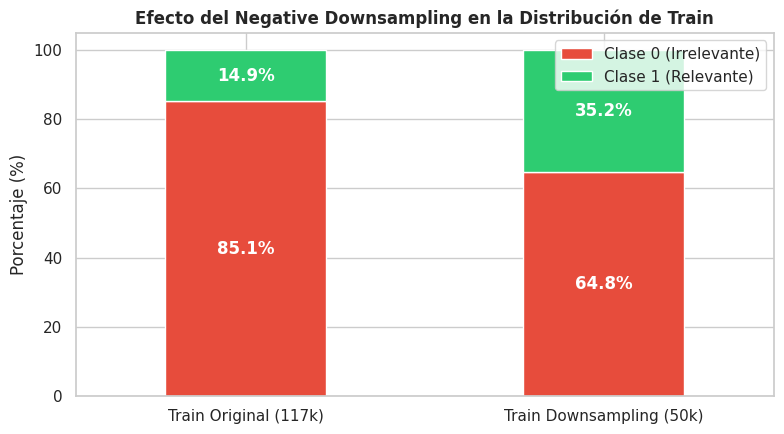

In [32]:
# Gráfico comparativo de la proporción de clases antes y después del submuestreo
prop_original = df_pares["label"].value_counts(normalize=True) * 100
prop_down = df_train_down["label"].value_counts(normalize=True) * 100

df_comp_prop = pd.DataFrame({
    "Train Original (117k)": prop_original,
    "Train Downsampling (50k)": prop_down
}, index=[0, 1])

ax = df_comp_prop.T.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], figsize=(8, 4.5), width=0.45)
plt.title("Efecto del Negative Downsampling en la Distribución de Train", fontsize=12, fontweight="bold")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=0)
plt.legend(["Clase 0 (Irrelevante)", "Clase 1 (Relevante)"], loc="upper right")

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5:
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f"{height:.1f}%", ha="center", va="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

## 2.3 Experimento 1: Arquitectura del Profesor ($32 \to 64 \to 128 \to 1$)

Para evaluar el comportamiento de la red y documentar el impacto de la regularización, implementamos la arquitectura de 3 capas ocultas de la Clase 4:

### Documentación de la Arquitectura (Pauta 4.2.2):
* **Capas y Neuronas:** Capa 1 (32) $\to$ Capa 2 (64) $\to$ Capa 3 (128) $\to$ Salida (1 neurona).
* **Funciones de Activación:** ReLU en las capas ocultas y Sigmoide en la salida para predicción probabilística binaria.
* **Función de Pérdida:** `binary_crossentropy`.
* **Optimizador:** Adam (`learning_rate=0.001`).
* **Épocas:** 100 épocas fijadas.

### Estrategia de Comparación (Pauta 4.2.3):
* **Modelo 1A (Sin Regularización):** Red base sin penalización ni Dropout durante 100 épocas.
* **Modelo 1B (Con Regularización):** Red con **Dropout (0.3)** en cada capa, penalización **$L_2$ (`l2(0.001)`)** en los pesos y **Early Stopping** (`patience=10`, `restore_best_weights=True`) monitoreando `val_loss`.

## Entrenamiento Modelo 1A (Profesor Sin Regularización — 100 Épocas)

In [34]:
# Callback para monitorear F1-Macro en Train y Dev durante las 100 épocas
class F1MacroLogger(tf.keras.callbacks.Callback):
    def __init__(self, X_train, y_train, X_val, y_val, batch_size=2048):
        super().__init__()
        np.random.seed(42)
        idx_s = np.random.choice(len(X_train), size=min(10000, len(X_train)), replace=False)
        self.X_tr, self.y_tr = X_train[idx_s], y_train[idx_s]
        self.X_val, self.y_val = X_val, y_val
        self.batch_size = batch_size
        self.train_f1, self.val_f1 = [], []

    def on_epoch_end(self, epoch, logs=None):
        pred_tr = (self.model.predict(self.X_tr, batch_size=self.batch_size, verbose=0) >= 0.5).astype(int).ravel()
        pred_val = (self.model.predict(self.X_val, batch_size=self.batch_size, verbose=0) >= 0.5).astype(int).ravel()
        self.train_f1.append(f1_score(self.y_tr, pred_tr, average='macro'))
        self.val_f1.append(f1_score(self.y_val, pred_val, average='macro'))

tf.random.set_seed(42)
np.random.seed(42)



In [ ]:
# --- MODELO 1A: Sin Regularización ---
model_1a = Sequential([
    Dense(32, activation='relu', input_shape=(5000,)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_1a.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='binary_crossentropy')
f1_log_1a = F1MacroLogger(X_train_mlp, y_train_mlp, X_dev_mlp, y_dev_mlp)

print("--- Entrenando Modelo 1A: Profesor Sin Regularización (100 épocas) ---")
history_1a = model_1a.fit(
    X_train_mlp, y_train_mlp,
    validation_data=(X_dev_mlp, y_dev_mlp),
    epochs=100, batch_size=128,
    callbacks=[f1_log_1a], verbose=1
)

# --- MODELO 1B: Con Regularización (Dropout + L2 + Early Stopping) ---
model_1b = Sequential([
    Dense(32, activation='relu', kernel_regularizer=l2(0.001), input_shape=(5000,)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_1b.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='binary_crossentropy')
f1_log_1b = F1MacroLogger(X_train_mlp, y_train_mlp, X_dev_mlp, y_dev_mlp)
early_stop_1b = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\n--- Entrenando Modelo 1B: Profesor Con Regularización (100 épocas máx con Early Stopping) ---")
history_1b = model_1b.fit(
    X_train_mlp, y_train_mlp,
    validation_data=(X_dev_mlp, y_dev_mlp),
    epochs=100, batch_size=128,
    callbacks=[early_stop_1b, f1_log_1b], verbose=1
)

## Curvas de Aprendizaje (Loss y F1-Score)

In [ ]:
# Gráficos comparativos de curvas de aprendizaje
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# 1. Pérdida Sin Regularización
axes[0, 0].plot(history_1a.history['loss'], label='Train Loss', color='#e74c3c')
axes[0, 0].plot(history_1a.history['val_loss'], label='Dev Loss', color='#c0392b', linestyle='--')
axes[0, 0].set_title('Modelo 1A (Sin Reg.): Pérdida', fontweight='bold')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Métrica F1-Macro Sin Regularización
axes[0, 1].plot(f1_log_1a.train_f1, label='Train F1-Macro', color='#e74c3c')
axes[0, 1].plot(f1_log_1a.val_f1, label='Dev F1-Macro', color='#c0392b', linestyle='--')
axes[0, 1].set_title('Modelo 1A (Sin Reg.): Métrica F1-Macro', fontweight='bold')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('F1-Score Macro')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Pérdida Con Regularización
axes[1, 0].plot(history_1b.history['loss'], label='Train Loss', color='#27ae60')
axes[1, 0].plot(history_1b.history['val_loss'], label='Dev Loss', color='#1e8449', linestyle='--')
axes[1, 0].set_title('Modelo 1B (Con Reg.): Pérdida con Early Stopping', fontweight='bold')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Métrica F1-Macro Con Regularización
axes[1, 1].plot(f1_log_1b.train_f1, label='Train F1-Macro', color='#27ae60')
axes[1, 1].plot(f1_log_1b.val_f1, label='Dev F1-Macro', color='#1e8449', linestyle='--')
axes[1, 1].set_title('Modelo 1B (Con Reg.): Métrica F1-Macro', fontweight='bold')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('F1-Score Macro')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.4 Experimento 2: Arquitectura en Embudo ($128 \to 64 \to 32 \to 1$)

### Justificación de la Comparación:
La red del profesor ($32 \to 64 \to 128$) fue pensada para una entrada pequeña de 21 variables tabulares. En nuestro problema la entrada es de **5.000 palabras (TF-IDF)**; comenzar con 32 neuronas comprime de forma abrupta el 99.4% de los rasgos en la primera capa.
Para verificar si una compresión gradual favorece la representación semántica, evaluamos una arquitectura en embudo ($128 \to 64 \to 32$) manteniendo exactamente el mismo entorno (Dropout 0.3, $L_2$ de 0.001, 100 épocas máximas y Early Stopping).

## Entrenamiento Modelo 2 (Embudo) y Curvas

In [ ]:
# --- MODELO 2: Arquitectura en Embudo (128 -> 64 -> 32 -> 1) ---
model_2 = Sequential([
    Dense(128, activation='relu', kernel_regularizer=l2(0.001), input_shape=(5000,)),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_2.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='binary_crossentropy')

f1_log_2 = F1MacroLogger(X_train_mlp, y_train_mlp, X_dev_mlp, y_dev_mlp)
early_stop_2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("--- Entrenando Modelo 2: Embudo Con Regularización (100 épocas máx con Early Stopping) ---")
history_2 = model_2.fit(
    X_train_mlp, y_train_mlp,
    validation_data=(X_dev_mlp, y_dev_mlp),
    epochs=100, batch_size=128,
    callbacks=[early_stop_2, f1_log_2], verbose=1
)

# Curvas de aprendizaje del Modelo 2
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_2.history['loss'], label='Train Loss', color='#2980b9')
axes[0].plot(history_2.history['val_loss'], label='Dev Loss', color='#1f618d', linestyle='--')
axes[0].set_title('Modelo 2 (Embudo): Curva de Pérdida', fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(f1_log_2.train_f1, label='Train F1-Macro', color='#2980b9')
axes[1].plot(f1_log_2.val_f1, label='Dev F1-Macro', color='#1f618d', linestyle='--')
axes[1].set_title('Modelo 2 (Embudo): Métrica F1-Macro', fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('F1-Macro')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2.5 Calibración del Umbral de Decisión (Threshold Tuning)

La capa de salida Sigmoide predice una probabilidad continua en $[0, 1]$. El umbral estándar de 0.5 fue diseñado para datasets simétricos ($50/50$).
En SQAC Dev, donde el 85.18% de las oraciones son irrelevantes, exigir un 50% de probabilidad genera falsos negativos. Sin reentrenar la red, barremos umbrales entre 0.20 y 0.55 sobre la mejor arquitectura regularizada para encontrar el balance óptimo entre Precisión y Recall que maximice el $F_1$-Macro.

## Barrido de Umbrales y Tabla Comparativa

In [ ]:
# Predicciones de probabilidad en Dev
prob_1a_dev = model_1a.predict(X_dev_mlp, batch_size=2048, verbose=0).ravel()
prob_1b_dev = model_1b.predict(X_dev_mlp, batch_size=2048, verbose=0).ravel()
prob_2_dev = model_2.predict(X_dev_mlp, batch_size=2048, verbose=0).ravel()

# Evaluación con umbral estándar 0.5
f1_1b_05 = f1_score(y_dev_mlp, (prob_1b_dev >= 0.5).astype(int), average='macro')
f1_2_05 = f1_score(y_dev_mlp, (prob_2_dev >= 0.5).astype(int), average='macro')

# Selección del modelo con mejor F1 en 0.5 para calibrar su umbral
if f1_2_05 >= f1_1b_05:
    mejor_prob = prob_2_dev
    nombre_ganador = "MLP Embudo (128->64->32)"
else:
    mejor_prob = prob_1b_dev
    nombre_ganador = "MLP Profesor (32->64->128)"

# Barrido de umbrales
umbrales = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
tabla_u = []
for u in umbrales:
    pred_u = (mejor_prob >= u).astype(int)
    tabla_u.append({
        "Umbral": u,
        "F1-Macro (Dev)": round(f1_score(y_dev_mlp, pred_u, average='macro'), 4),
        "Accuracy (Dev)": round(accuracy_score(y_dev_mlp, pred_u), 4)
    })

df_calibracion = pd.DataFrame(tabla_u)
print(f"Barrido de Umbrales sobre {nombre_ganador}:")
display(df_calibracion)

fila_optima = df_calibracion.sort_values(by="F1-Macro (Dev)", ascending=False).iloc[0]
u_optimo = fila_optima["Umbral"]
f1_optimo = fila_optima["F1-Macro (Dev)"]
acc_optimo = fila_optima["Accuracy (Dev)"]

# Tabla Comparativa Final de la Etapa 2
tabla_final_etapa2 = pd.DataFrame({
    "Modelo Evaluado": [
        "Baseline: Regresión Logística (Etapa 1)",
        "Modelo 1A: MLP Profesor Sin Reg. (Umbral 0.5)",
        "Modelo 1B: MLP Profesor Con Reg. (Umbral 0.5)",
        "Modelo 2: MLP Embudo Con Reg. (Umbral 0.5)",
        f"Mejor Modelo ({nombre_ganador}) con Umbral Calibrado ({u_optimo})"
    ],
    "F1-Score Macro (Dev)": [
        BASELINE_F1_DEV,
        f1_score(y_dev_mlp, (prob_1a_dev >= 0.5).astype(int), average='macro'),
        f1_1b_05,
        f1_2_05,
        f1_optimo
    ],
    "Accuracy (Dev)": [
        BASELINE_ACC_DEV,
        accuracy_score(y_dev_mlp, (prob_1a_dev >= 0.5).astype(int)),
        accuracy_score(y_dev_mlp, (prob_1b_dev >= 0.5).astype(int)),
        accuracy_score(y_dev_mlp, (prob_2_dev >= 0.5).astype(int)),
        acc_optimo
    ]
})

print("=" * 80)
print("             TABLA FINAL DE COMPARACIÓN EN DEV (ETAPAS 1 Y 2)")
print("=" * 80)
display(tabla_final_etapa2)

pred_ganador = (mejor_prob >= u_optimo).astype(int)
print(f"\nReporte de Clasificación Detallado del Mejor Modelo en Dev (Umbral = {u_optimo}):")
print(classification_report(y_dev_mlp, pred_ganador, target_names=["Irrelevante (0)", "Relevante (1)"]))

## 2.6 Conclusiones de la Etapa 2 y Análisis de Resultados

Una vez ejecutados los modelos y calibrado el umbral de decisión, se documentan los siguientes hallazgos:

1. **Comparación contra el Baseline:** La tabla final permite constatar la variación del F1-Score Macro respecto a la marca de referencia del clasificador lineal ($0.5547$). *(Completar aquí con el valor obtenido del mejor modelo y el porcentaje de cambio)*.
2. **Impacto de la Regularización:** El Modelo 1A evidenció sobreajuste al cabo de las épocas, mientras que el Modelo 1B aplicó Early Stopping interrumpiendo el entrenamiento de forma temprana para evitar la degradación en validación.
3. **Comparación de Arquitecturas:** Contrastar el rendimiento entre la estructura expansiva del docente ($32 \to 64 \to 128$) y la estructura compresiva en embudo ($128 \to 64 \to 32$) frente a una entrada de 5.000 componentes TF-IDF. *(Completar indicando cuál obtuvo mejor F1-Macro)*.
4. **Efecto del Umbral:** Ajustar el umbral por debajo de 0.5 compensó el desbalance de clases de Dev, modificando el equilibrio entre Precisión y Recall.
5. **Transición a la Etapa 3:** A pesar de las mejoras alcanzadas con capas densas no lineales, los falsos negativos por sinonimia (identificados en el análisis manual) persisten debido a la naturaleza discreta de TF-IDF, justificando el paso a representaciones densas mediante **Word Embeddings**.